# Fixed-Estimation Results: Visualization

Visualizes sensitivity and correlation artifacts saved as CSVs in
`results/fixed_estimation/`. This notebook is pure read-from-CSV + plot -- it
does NOT import the estimator, does NOT run ipopt, and does NOT rebuild any model.

The sensitivity heatmap and correlation matrices intentionally mirror
`plots_first_estimation.ipynb` so the literature (fixed) and fitted (first) analyses
are directly comparable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle as MplRect
from matplotlib.transforms import blended_transform_factory
from pathlib import Path

RESULTS_DIR = Path('results/fixed_estimation')
FIG_DIR = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

corr_df = pd.read_csv(RESULTS_DIR / 'correlation.csv', index_col=0)

# Stack per-condition sensitivity CSVs into G_stack of shape (n_cond, 18, 37)
sens_files = sorted((RESULTS_DIR / 'sensitivity').glob('*.csv'))
G_list = []
row_kind = None
row_name = None
param_cols = None
cond_names = []

for fp in sens_files:
    df = pd.read_csv(fp)
    if row_kind is None:
        row_kind = df['kind'].tolist()
        row_name = df['name'].tolist()
        param_cols = [c for c in df.columns if c not in ('kind', 'name')]
    else:
        assert df['kind'].tolist() == row_kind, 'row_kind mismatch across conditions'
        assert df['name'].tolist() == row_name, 'row_name mismatch across conditions'
    G_list.append(df[param_cols].values.astype(float))
    cond_names.append(fp.stem)

G_stack = np.stack(G_list, axis=0)  # shape: (n_cond, 18, 37)
print(f'G_stack shape: {G_stack.shape}, conditions: {len(cond_names)}')

PARAMS = list(corr_df.columns)
assert PARAMS == param_cols, 'PARAMS order mismatch between corr_df and sensitivity param columns'
print(f'PARAMS verified ({len(PARAMS)} params)')


G_stack shape: (22, 18, 37), conditions: 22
PARAMS verified (37 params)


## Shared Style

In [2]:
# Shared style block -- copied verbatim from sensitivity_analysis.ipynb cells 4c2bbb4e and 3bd5d160

import sys, os; sys.path.insert(0, os.path.join(os.path.abspath('.'), 'src'))
from utils import REACTION_GROUPS as reaction_groups, PARAM_LATEX_LABELS as _param_labels_orig, TYPE_COLOR, KCAT0 as _KCAT0, PTS0 as _PTS0
def _t0(i): return 'pts' if i in _PTS0 else ('kcat' if i in _KCAT0 else 'km')
_rank = {'kcat': 0, 'km': 1, 'pts': 0}
_perm = []
for _nm, _is, _ie, _c in reaction_groups:
    _perm += sorted(range(_is, _ie + 1), key=lambda i: (_rank[_t0(i)], i))

param_labels_p = [_param_labels_orig[i] for i in _perm]
KCAT_IDX = {p for p, o in enumerate(_perm) if o in _KCAT0}
PTS_IDX  = {p for p, o in enumerate(_perm) if o in _PTS0}

def _type_color(i):
    if i in PTS_IDX:  return TYPE_COLOR['pts']
    if i in KCAT_IDX: return TYPE_COLOR['kcat']
    return TYPE_COLOR['km']

def styled_matrix_heatmap(M_permuted, vmin, vmax, cbar_label, savepath,
                          cmap_name='RdBu_r', extend='neither'):
    """
    Render a pre-permuted square matrix with the reference styling from
    sensitivity_analysis.ipynb (cell 4c2bbb4e): type-colored ticks, white cell
    gridlines, heavy block separators, colored on-diagonal frames, top+right
    reaction strips, hidden spines, size-matched colorbar, savefig at dpi=300.
    rcParams are saved and restored around the call.
    """
    _rc_save = {k: mpl.rcParams[k] for k in (
        'font.family', 'font.size', 'axes.linewidth', 'mathtext.fontset')}
    mpl.rcParams.update({
        'font.family':     'sans-serif',
        'font.size':        9,
        'axes.linewidth':   0.6,
        'mathtext.fontset': 'dejavusans',
    })

    cmap = mpl.colormaps[cmap_name].copy()
    cmap.set_bad('#e9e9ec')

    GAP      = 0.35
    STRIP    = 1.4
    TICK_FS  = 11
    STRIP_FS = 9

    n = M_permuted.shape[0]
    fig, ax = plt.subplots(figsize=(10.5, 10.5), dpi=200)
    im = ax.imshow(M_permuted, cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='none', aspect='equal')

    ax.set_xlim(-0.5, n - 0.5 + GAP + STRIP)
    ax.set_ylim(n - 0.5, -0.5 - GAP - STRIP)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(param_labels_p, rotation=90, fontsize=TICK_FS, ha='center')
    ax.set_yticklabels(param_labels_p, fontsize=TICK_FS)

    for i, t in enumerate(ax.get_xticklabels()):
        t.set_color(_type_color(i)); t.set_fontweight('semibold')
    for i, t in enumerate(ax.get_yticklabels()):
        t.set_color(_type_color(i)); t.set_fontweight('semibold')
    ax.tick_params(length=2, width=0.5, pad=2)

    for k in np.arange(-0.5, n, 1):
        ax.plot([-0.5, n - 0.5], [k, k], color='white', lw=0.5, zorder=1)
        ax.plot([k, k], [-0.5, n - 0.5], color='white', lw=0.5, zorder=1)

    for name, i_s, i_e, col in reaction_groups:
        if i_s != 0:
            ax.plot([i_s - 0.5, i_s - 0.5], [-0.5, n - 0.5], color='#2b2b2b', lw=1.1, zorder=3)
            ax.plot([-0.5, n - 0.5], [i_s - 0.5, i_s - 0.5], color='#2b2b2b', lw=1.1, zorder=3)
        ax.add_patch(MplRect((i_s - 0.5, i_s - 0.5), i_e - i_s + 1, i_e - i_s + 1,
                             fill=False, edgecolor=col, lw=1.6, zorder=5))
    ax.add_patch(MplRect((-0.5, -0.5), n, n, fill=False, edgecolor='#2b2b2b', lw=1.1, zorder=6))

    top_y   = -0.5 - GAP - STRIP
    right_x = n - 0.5 + GAP
    for name, i_s, i_e, col in reaction_groups:
        w = i_e - i_s + 1
        ax.add_patch(MplRect((i_s - 0.5, top_y), w, STRIP,
                             facecolor=col, edgecolor='white', lw=1.0, zorder=4))
        ax.text((i_s + i_e) / 2, top_y + STRIP / 2, name, ha='center', va='center',
                fontsize=STRIP_FS, fontweight='bold', color='white', zorder=5)
        ax.add_patch(MplRect((right_x, i_s - 0.5), STRIP, w,
                             facecolor=col, edgecolor='white', lw=1.0, zorder=4))
        ax.text(right_x + STRIP / 2, (i_s + i_e) / 2, name, ha='center', va='center',
                fontsize=STRIP_FS, fontweight='bold', color='white', rotation=270, zorder=5)

    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03, shrink=0.6, extend=extend)
    cbar.set_label(cbar_label, fontsize=11, labelpad=4)
    cbar.ax.tick_params(labelsize=9, length=3, width=0.5)
    cbar.outline.set_linewidth(0.6)

    fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

    mpl.rcParams.update(_rc_save)
print('Shared style block loaded.')
print(f'_perm length: {len(_perm)}')
print(f'KCAT_IDX positions: {sorted(KCAT_IDX)}')
print(f'PTS_IDX  positions: {sorted(PTS_IDX)}')


Shared style block loaded.
_perm length: 37
KCAT_IDX positions: [5, 8, 13, 17, 20, 26, 31, 34]
PTS_IDX  positions: [0, 1, 2, 3, 4]


## Sensitivity Analysis

Mean **relative** sensitivity $|d\ln y / d\ln\theta| = |(dy/d\theta)\,\theta_j / y_i|$
averaged over all conditions, split by concentration block (rows 0-8) and flux block
(rows 9-17) with separate (log) color scales.

Relative sensitivity rescales the saved absolute sensitivities by the literature
parameter value $\theta_j$ and the predicted output magnitude $y_i$, giving a
dimensionless, comparable-across-outputs measure. All 9 balanced metabolite
concentrations have finite model predictions (including previously-unmeasured
C_g3p, C_pgp, C_2pg), so all rows are normalized and appear in the heatmap.

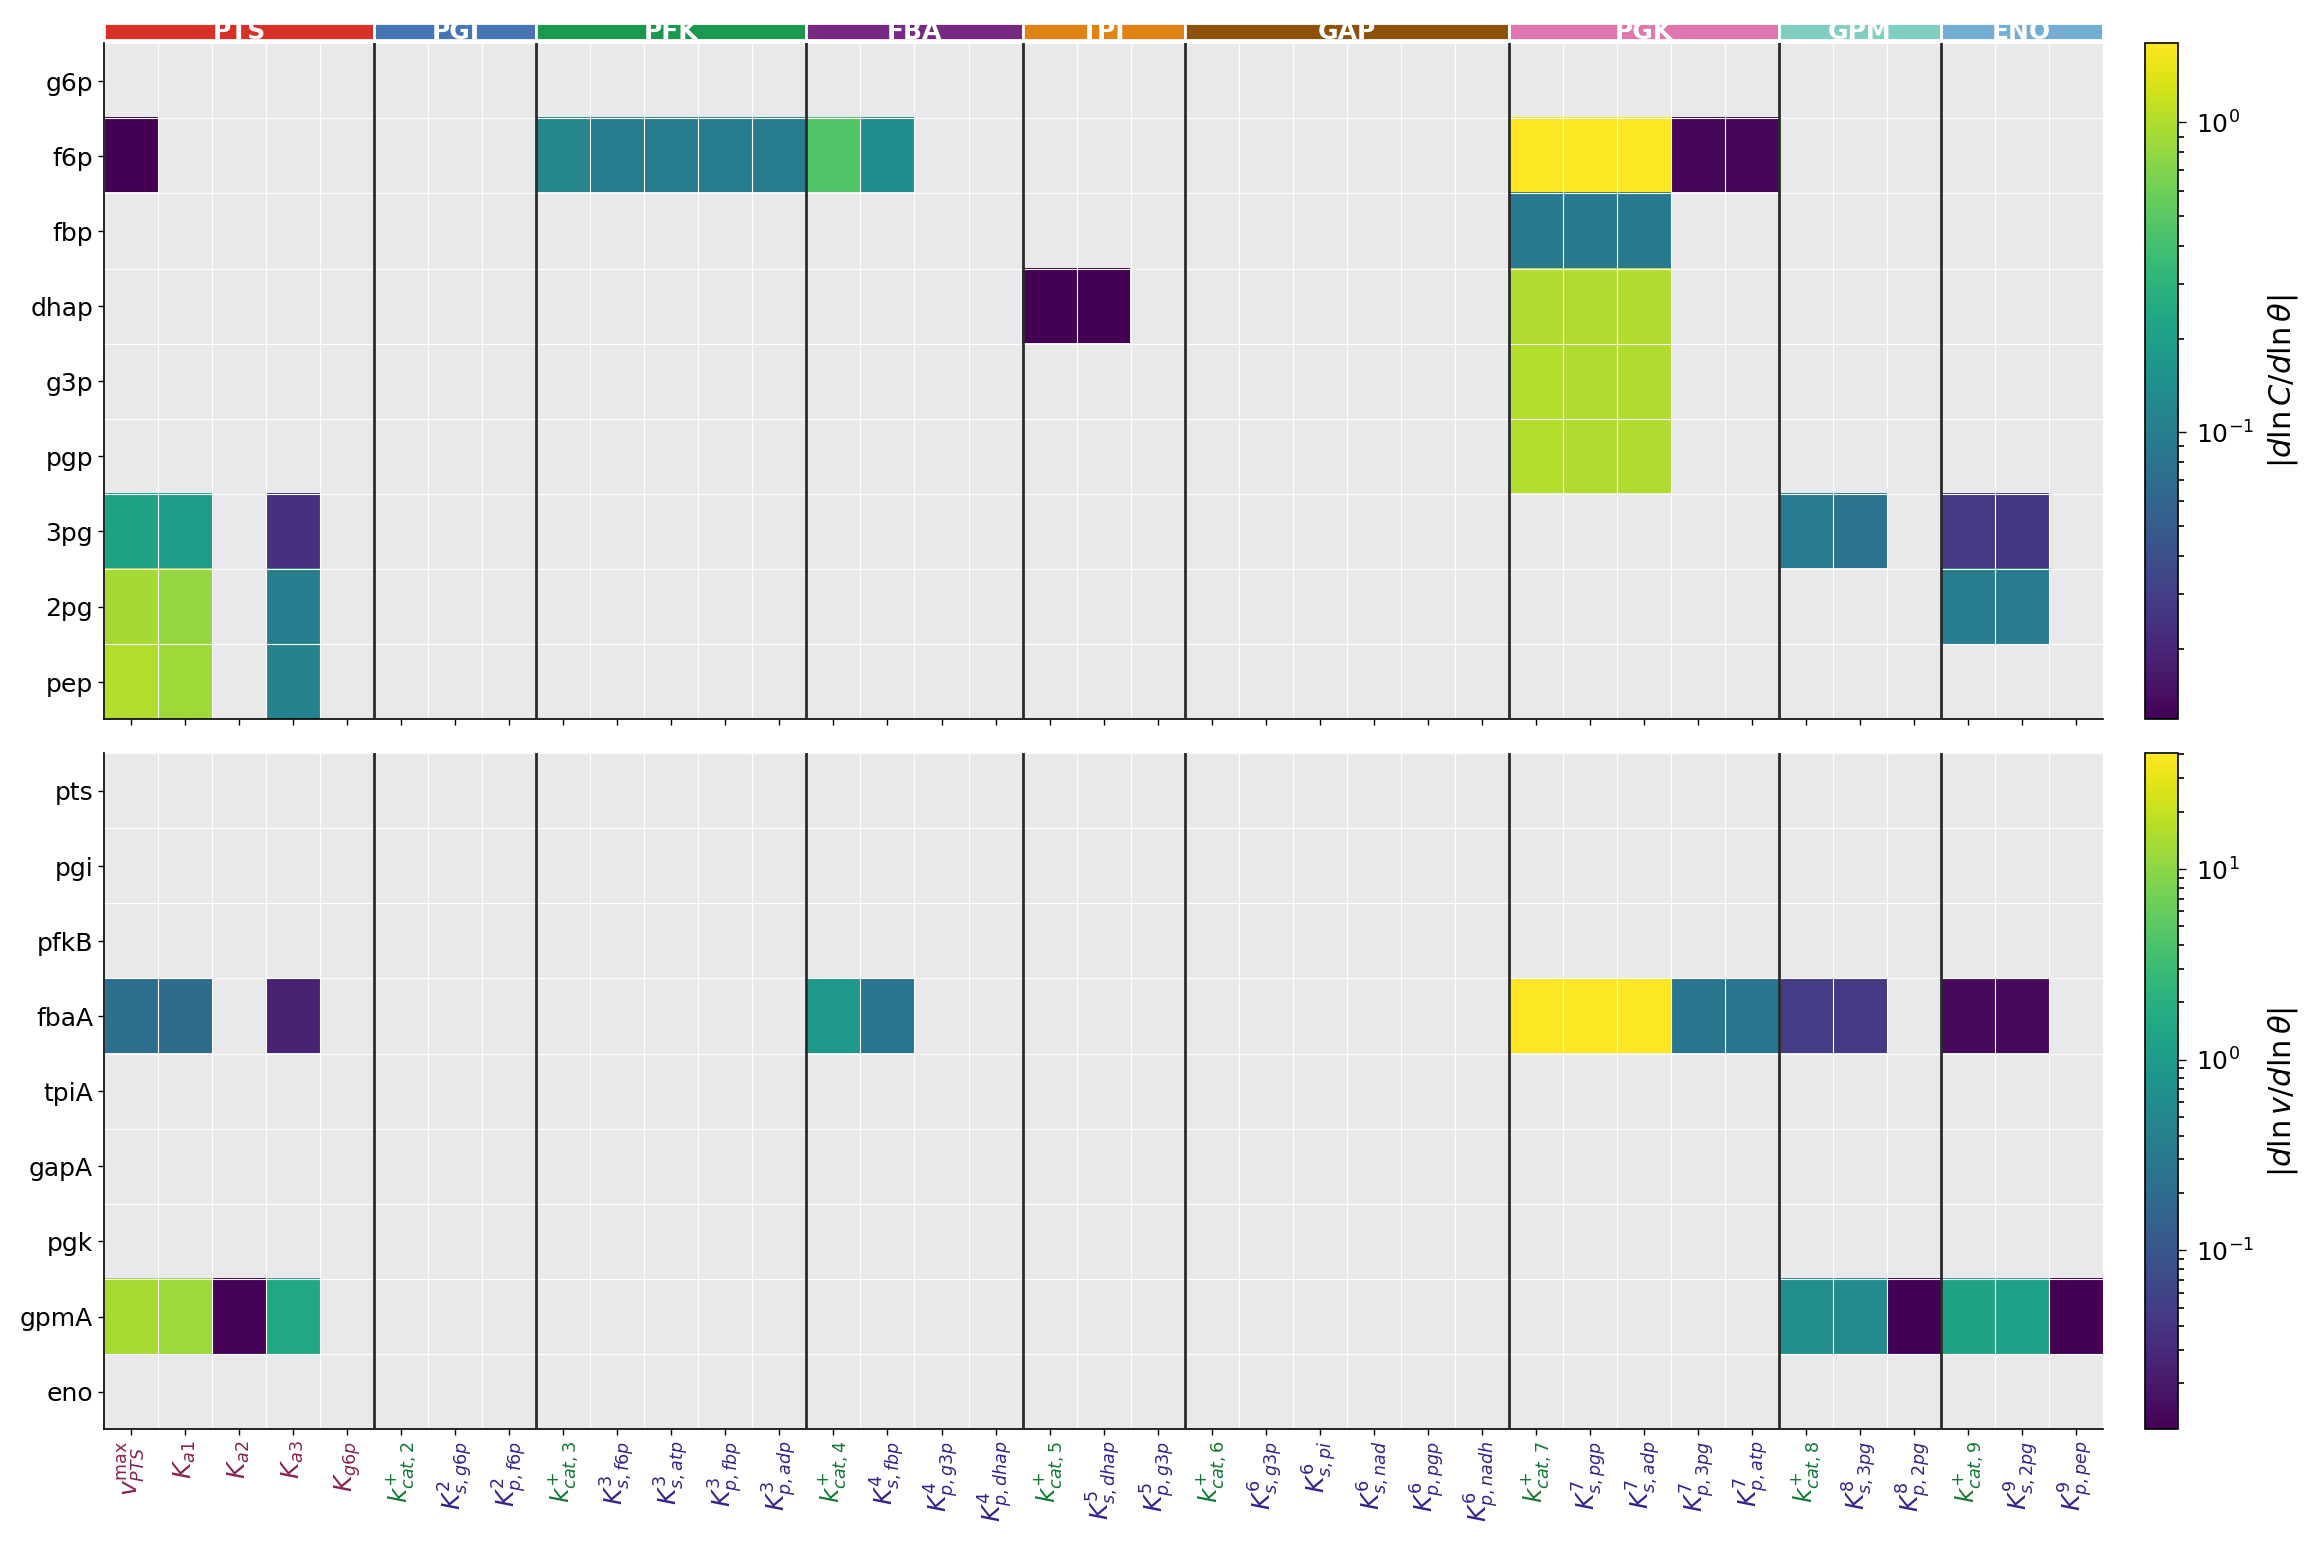

Saved: sensitivity_rel_mean.pdf
Thresholds: conc >= 0.01, flux >= 0.01
Log scale: conc=True, flux=True
Cells shown: conc 42/333, flux 24/333
Heatmap rows: conc=9, flux=9, total=18


In [3]:
# Sensitivity heatmap: RELATIVE mean over conditions, split concentration/flux scales
import warnings
from matplotlib.colors import LogNorm

# all 22 conditions; all 9 concentration rows now have finite model predictions.
theta_fit = pd.read_csv(RESULTS_DIR / 'theta_lit.csv', index_col=0)['value']
pred_fit = pd.read_csv(RESULTS_DIR / 'predictions.csv', index_col=0)

theta_vec = theta_fit.reindex(param_cols).to_numpy(dtype=float)            # (37,)
pred_aligned = pred_fit.reindex(index=cond_names, columns=row_name)        # (n_cond, 18)
Y = pred_aligned.to_numpy(dtype=float)
Y = np.where((Y > 0) & np.isfinite(Y), Y, np.nan)                          # guard div

rel_stack = G_stack * theta_vec[None, None, :] / Y[:, :, None]            # (n_cond, 18, 37)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)                        # all-NaN rows
    G_rel_mean = np.nanmean(np.abs(rel_stack), axis=0)                      # (18, 37)

# Threshold: cells whose mean |relative sensitivity| is below the threshold are
# masked (rendered grey).
SENS_THRESH_CONC = 0.01     # keeps params that move a concentration by >~10%
SENS_THRESH_FLUX = 0.01   # keeps the upper-quartile (most sensitive) flux cells

CONC_LOG_SCALE = True
FLUX_LOG_SCALE = True

G_plot = G_rel_mean[:, _perm]

n_par = G_plot.shape[1]
conc_block = G_plot[:9, :]
flux_block  = G_plot[9:, :]

# Apply thresholds: values below the cut become NaN (drawn with set_bad grey)
conc_block = np.where(conc_block >= SENS_THRESH_CONC, conc_block, np.nan)
flux_block = np.where(flux_block >= SENS_THRESH_FLUX, flux_block, np.nan)

def _imshow_kw(block, use_log):
    """Build imshow color kwargs: LogNorm when use_log else linear 0..max.
    The log vmin is a robust 5th-percentile floor of positive cells so a few
    tiny values do not stretch the dynamic range."""
    pos = block[np.isfinite(block) & (block > 0)]
    if pos.size == 0:
        return dict(vmin=0, vmax=1.0)
    vmax = float(pos.max())
    if use_log:
        vmin = float(np.percentile(pos, 5))
        vmin = max(min(vmin, vmax / 10.0), vmax * 1e-9)
        return dict(norm=LogNorm(vmin=vmin, vmax=vmax))
    return dict(vmin=0, vmax=vmax)

# Row labels: strip 'C_' prefix for concentration, 'v_' prefix for flux
y_labels_conc = [nm.replace('C_', '') for nm in row_name[:9]]
y_labels_flux = [nm.replace('v_', '') for nm in row_name[9:]]

TOP_STRIP_Y = 1.004
TOP_STRIP_H = 0.026
STRIP_FS = 9

mpl.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':        9,
    'axes.linewidth':   0.6,
    'mathtext.fontset': 'dejavusans',
})

fig = plt.figure(figsize=(13.5, 9.0), dpi=200)
gs = fig.add_gridspec(2, 1, height_ratios=[9, 9], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

cmap_seq = mpl.colormaps['viridis'].copy()
cmap_seq.set_bad('#e9e9ec')

im_top = ax_top.imshow(conc_block, aspect='auto', cmap=cmap_seq,
                        interpolation='none', **_imshow_kw(conc_block, CONC_LOG_SCALE))
im_bot = ax_bot.imshow(flux_block, aspect='auto', cmap=cmap_seq,
                        interpolation='none', **_imshow_kw(flux_block, FLUX_LOG_SCALE))

cbar_top = fig.colorbar(im_top, ax=ax_top, fraction=0.025, pad=0.02)
cbar_top.set_label(r'$|d\ln C / d\ln\theta|$', fontsize=11, labelpad=4)
cbar_top.ax.tick_params(labelsize=9, length=3, width=0.5)
cbar_top.outline.set_linewidth(0.6)

cbar_bot = fig.colorbar(im_bot, ax=ax_bot, fraction=0.025, pad=0.02)
cbar_bot.set_label(r'$|d\ln v / d\ln\theta|$', fontsize=11, labelpad=4)
cbar_bot.ax.tick_params(labelsize=9, length=3, width=0.5)
cbar_bot.outline.set_linewidth(0.6)

ax_top.set_yticks(range(9))
ax_top.set_yticklabels(y_labels_conc, fontsize=9)
ax_bot.set_yticks(range(9))
ax_bot.set_yticklabels(y_labels_flux, fontsize=9)

plt.setp(ax_top.get_xticklabels(), visible=False)
ax_bot.set_xticks(range(n_par))
ax_bot.set_xticklabels(param_labels_p, rotation=90, fontsize=9, ha='center')
for i, t in enumerate(ax_bot.get_xticklabels()):
    t.set_color(_type_color(i))
    t.set_fontweight('semibold')
ax_bot.tick_params(length=2, width=0.5, pad=2)
ax_top.tick_params(length=2, width=0.5, pad=2)

for ax, nrows in [(ax_top, 9), (ax_bot, 9)]:
    for k in np.arange(-0.5, n_par, 1):
        ax.plot([k, k], [-0.5, nrows - 0.5], color='white', lw=0.4, zorder=1)
    for k in np.arange(-0.5, nrows, 1):
        ax.plot([-0.5, n_par - 0.5], [k, k], color='white', lw=0.4, zorder=1)

for ax in [ax_top, ax_bot]:
    for _nm, i_s, i_e, _col in reaction_groups:
        if i_s != 0:
            ax.plot([i_s - 0.5, i_s - 0.5], [-0.5, 8.5], color='#2b2b2b', lw=1.0, zorder=3)

# Top reaction strip via blended_transform_factory over ax_top
trans_top = blended_transform_factory(ax_top.transData, ax_top.transAxes)
for name, i_s, i_e, col in reaction_groups:
    ax_top.add_patch(MplRect((i_s - 0.5, TOP_STRIP_Y), i_e - i_s + 1, TOP_STRIP_H,
                             transform=trans_top, facecolor=col, edgecolor='white',
                             lw=1.0, clip_on=False, zorder=4))
    ax_top.text((i_s + i_e) / 2, TOP_STRIP_Y + TOP_STRIP_H / 2, name,
                transform=trans_top, ha='center', va='center',
                fontsize=STRIP_FS, fontweight='bold', color='white',
                clip_on=False, zorder=5)

for s in ('top', 'right'):
    ax_top.spines[s].set_visible(False)
    ax_bot.spines[s].set_visible(False)

fig.savefig(FIG_DIR / 'sensitivity_rel_mean.pdf', dpi=300, bbox_inches='tight')
plt.show()

mpl.rcParams.update(mpl.rcParamsDefault)
n_shown_conc = int(np.isfinite(conc_block).sum())
n_shown_flux = int(np.isfinite(flux_block).sum())
print('Saved: sensitivity_rel_mean.pdf')
print(f'Thresholds: conc >= {SENS_THRESH_CONC}, flux >= {SENS_THRESH_FLUX}')
print(f'Log scale: conc={CONC_LOG_SCALE}, flux={FLUX_LOG_SCALE}')
print(f'Cells shown: conc {n_shown_conc}/{conc_block.size}, flux {n_shown_flux}/{flux_block.size}')
print(f'Heatmap rows: conc={conc_block.shape[0]}, flux={flux_block.shape[0]}, total={conc_block.shape[0]+flux_block.shape[0]}')


## Correlation Matrix

Parameter correlation matrix $r_{ij}$: full (unmasked) and masked ($|r| \geq 0.9$ only).

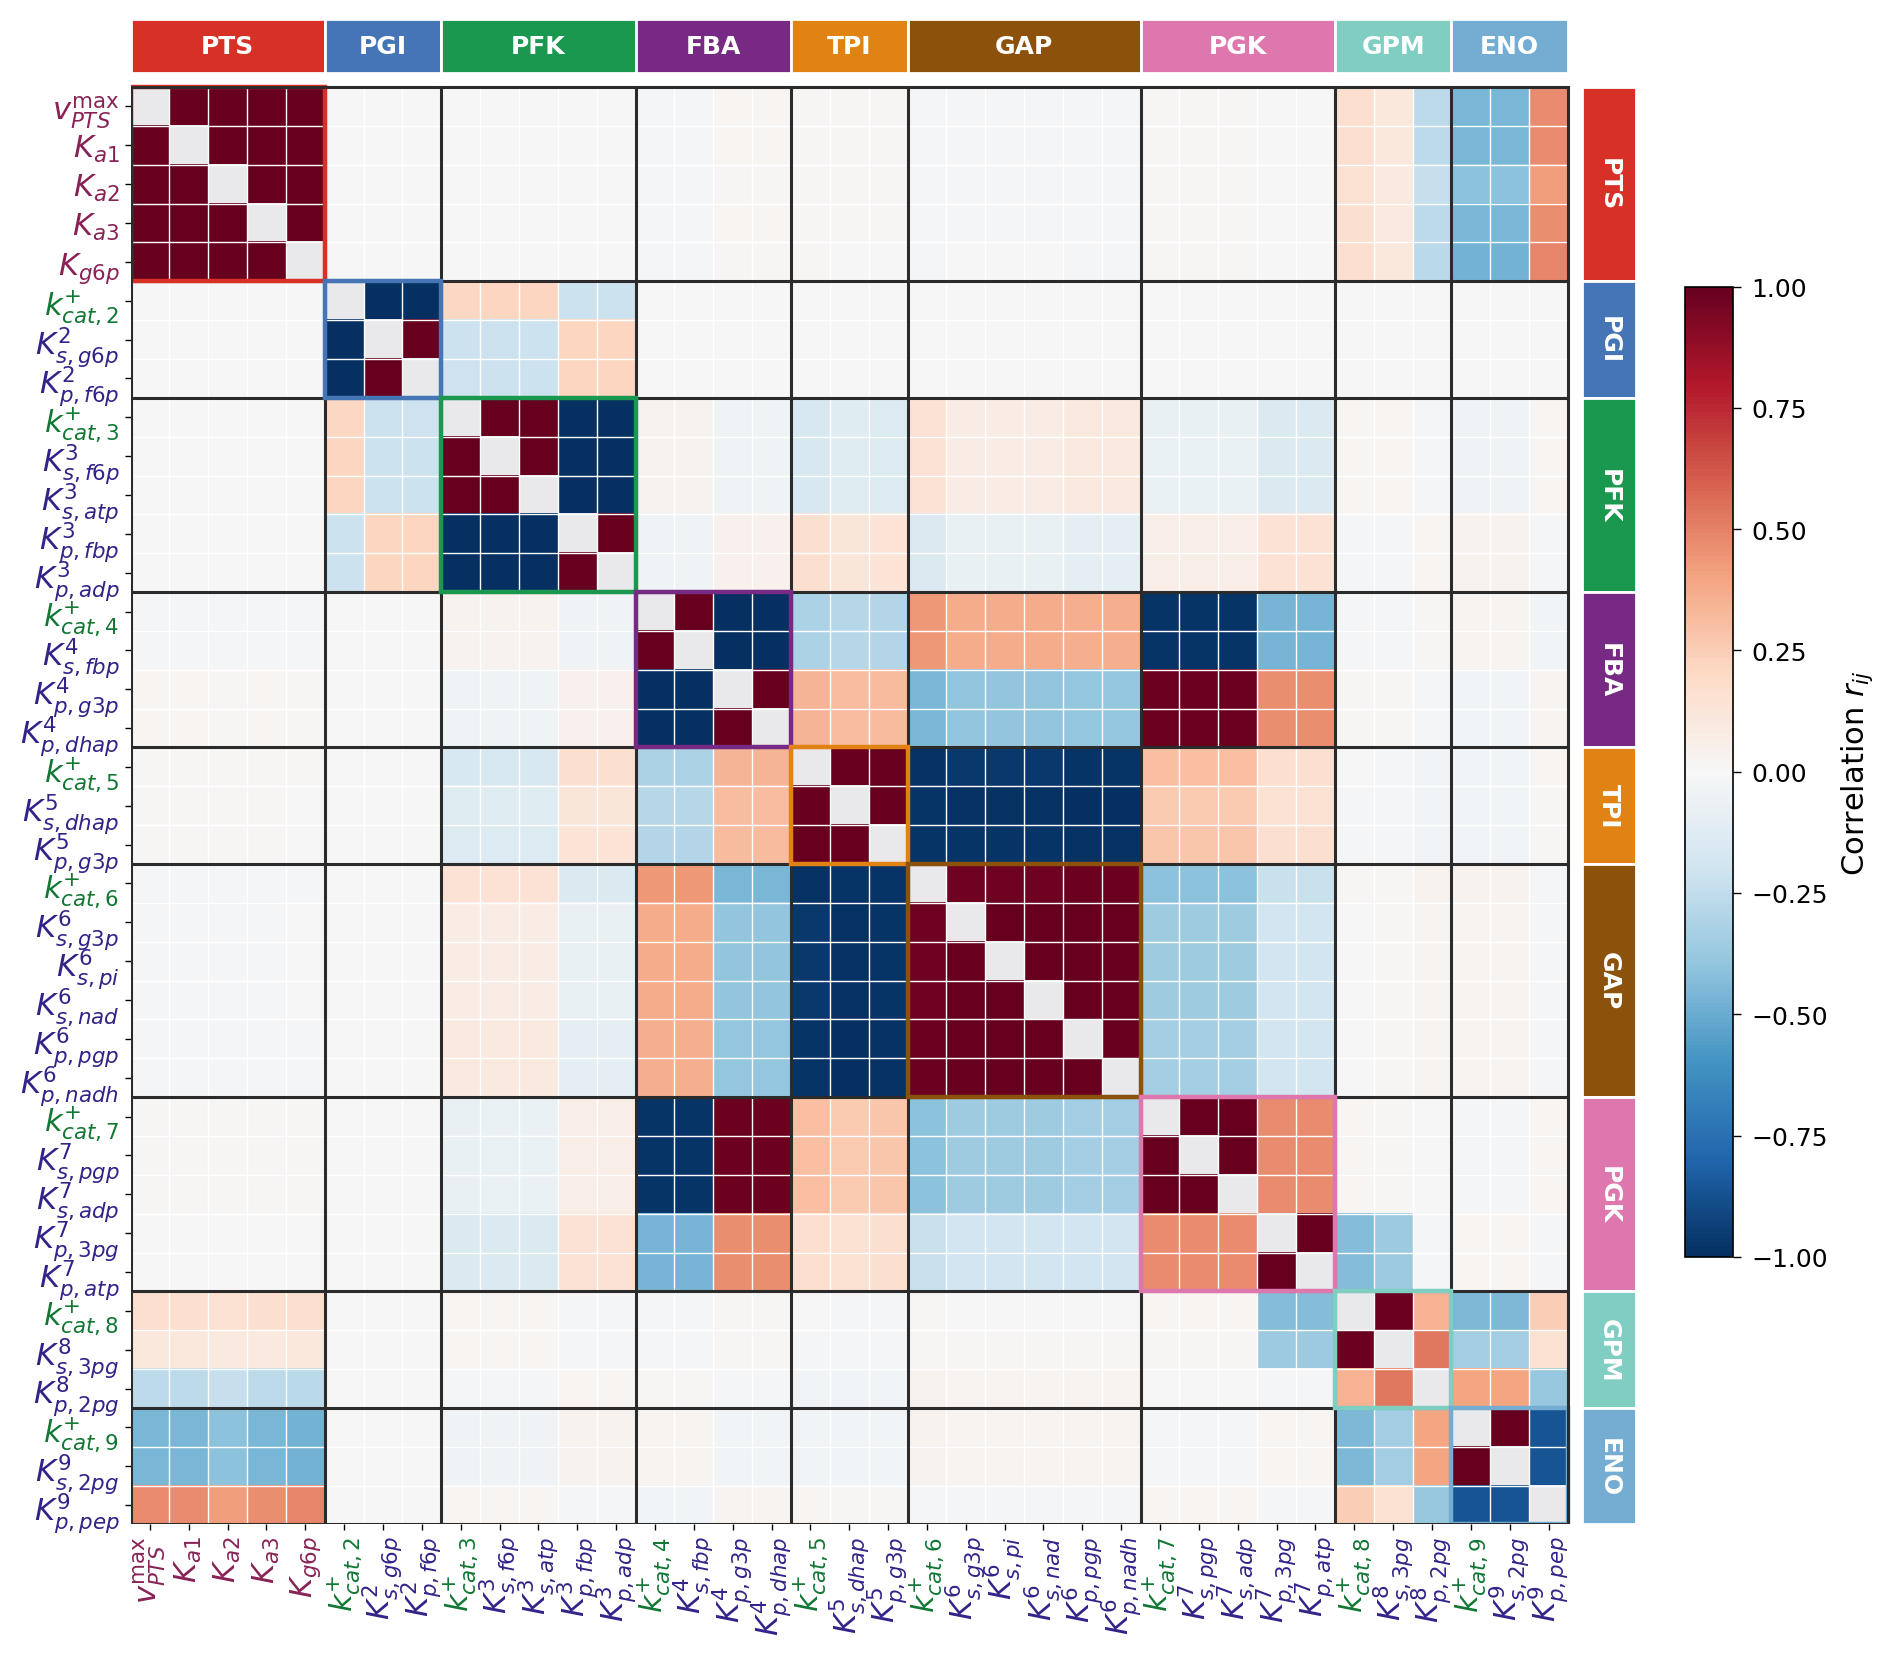

Saved: corr_not_masked.pdf


In [4]:
# Correlation heatmap, unmasked (diagonal -> NaN)
corr_p = corr_df.values[np.ix_(_perm, _perm)].copy().astype(float)
np.fill_diagonal(corr_p, np.nan)

styled_matrix_heatmap(
    corr_p, -1, 1,
    r'Correlation $r_{ij}$',
    FIG_DIR / 'corr_not_masked.pdf'
)
print('Saved: corr_not_masked.pdf')


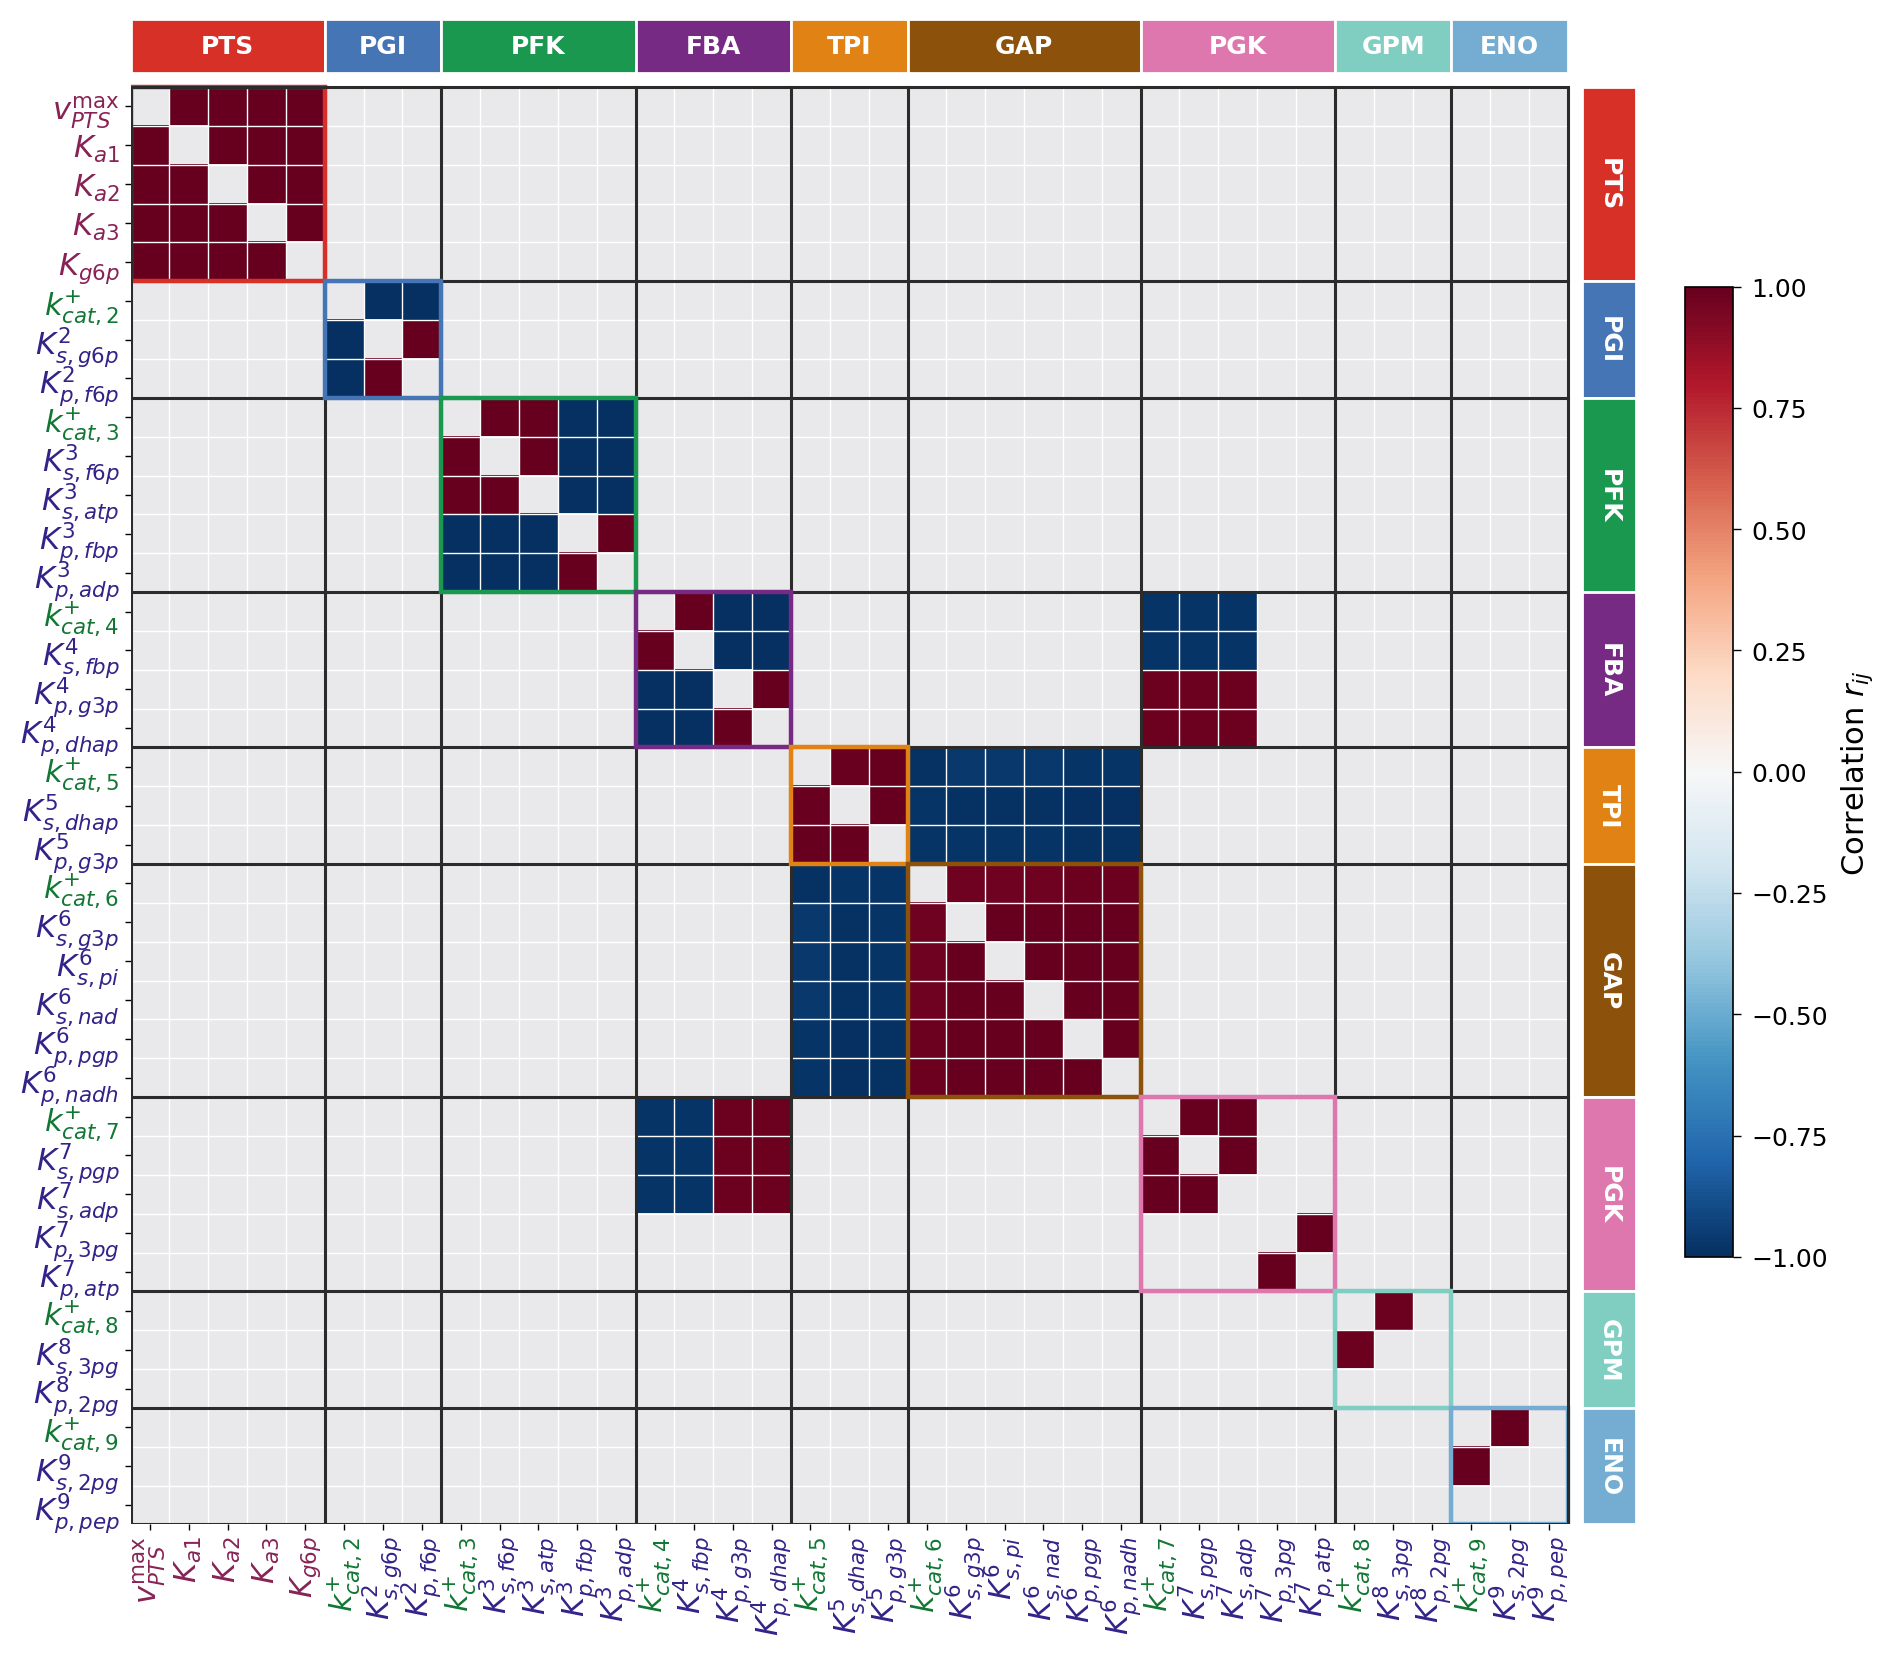

Saved: corr_masked.pdf


In [5]:
# Correlation heatmap, masked: show only |r| >= 0.9 (diagonal -> NaN)
corr_p_full = corr_df.values[np.ix_(_perm, _perm)].copy().astype(float)
corr_masked = np.where(np.abs(corr_p_full) >= 0.90, corr_p_full, np.nan)
np.fill_diagonal(corr_masked, np.nan)

styled_matrix_heatmap(
    corr_masked, -1, 1,
    r'Correlation $r_{ij}$',
    FIG_DIR / 'corr_masked.pdf'
)
print('Saved: corr_masked.pdf')


## Correlated-Pairs Table ($|r| \geq 0.9$)

In [6]:
# Correlated-pairs LaTeX table: pairs with |r| >= 0.9
# Reconstruct param_latex from the ORIGINAL ALL_PARAMS order (= list(corr_df.columns))
all_params_orig = list(corr_df.columns)
param_latex = {k: _param_labels_orig[j] for j, k in enumerate(all_params_orig)}

pairs = []
n_params = len(all_params_orig)
corr_vals = corr_df.values

for i in range(n_params):
    for j in range(i + 1, n_params):
        r = corr_vals[i, j]
        if np.isfinite(r) and abs(r) >= 0.9:
            pairs.append({
                'param_i': param_latex[all_params_orig[i]],
                'param_j': param_latex[all_params_orig[j]],
                'r': round(r, 4)
            })

pairs_df = pd.DataFrame(pairs, columns=['param_i', 'param_j', 'r'])
pairs_df = pairs_df.sort_values('r', key=abs, ascending=False).reset_index(drop=True)

print(f'Number of correlated pairs (|r| >= 0.9) over all 37 params: {len(pairs_df)}')
print(pairs_df.to_latex(index=False))


Number of correlated pairs (|r| >= 0.9) over all 37 params: 83
\begin{tabular}{llr}
\toprule
param_i & param_j & r \\
\midrule
$K_{a1}$ & $K_{g6p}$ & 1.009500 \\
$v^{\max}_{PTS}$ & $K_{g6p}$ & 1.009400 \\
$K_{a3}$ & $K_{g6p}$ & 1.009300 \\
$K_{a2}$ & $K_{g6p}$ & 1.003400 \\
$K_{s,pi}^{6}$ & $K_{s,nad}^{6}$ & 1.000000 \\
$K_{p,fbp}^{3}$ & $k^{+}_{cat,3}$ & -1.000000 \\
$K_{p,adp}^{3}$ & $k^{+}_{cat,3}$ & -1.000000 \\
$K_{s,fbp}^{4}$ & $k^{+}_{cat,4}$ & 1.000000 \\
$K_{p,g3p}^{4}$ & $K_{p,dhap}^{4}$ & 1.000000 \\
$K_{s,g3p}^{6}$ & $K_{s,pi}^{6}$ & 1.000000 \\
$K_{s,g3p}^{6}$ & $K_{s,nad}^{6}$ & 1.000000 \\
$v^{\max}_{PTS}$ & $K_{a1}$ & 1.000000 \\
$K_{p,pgp}^{6}$ & $K_{p,nadh}^{6}$ & 1.000000 \\
$K_{s,atp}^{3}$ & $k^{+}_{cat,3}$ & 1.000000 \\
$k^{+}_{cat,7}$ & $K_{s,pgp}^{7}$ & 1.000000 \\
$k^{+}_{cat,7}$ & $K_{s,adp}^{7}$ & 1.000000 \\
$K_{s,pgp}^{7}$ & $K_{s,adp}^{7}$ & 1.000000 \\
$K_{p,3pg}^{7}$ & $K_{p,atp}^{7}$ & 1.000000 \\
$K_{p,fbp}^{3}$ & $K_{p,adp}^{3}$ & 1.000000 \\
$k^{+}_{c

Metabolites: plotted 103 points  (predicted range 0.010..0.982, 0 negative) -- all shown, none dropped
Fluxes: plotted 198 points  (predicted range -0.330..1.203, 82 negative) -- all shown, none dropped


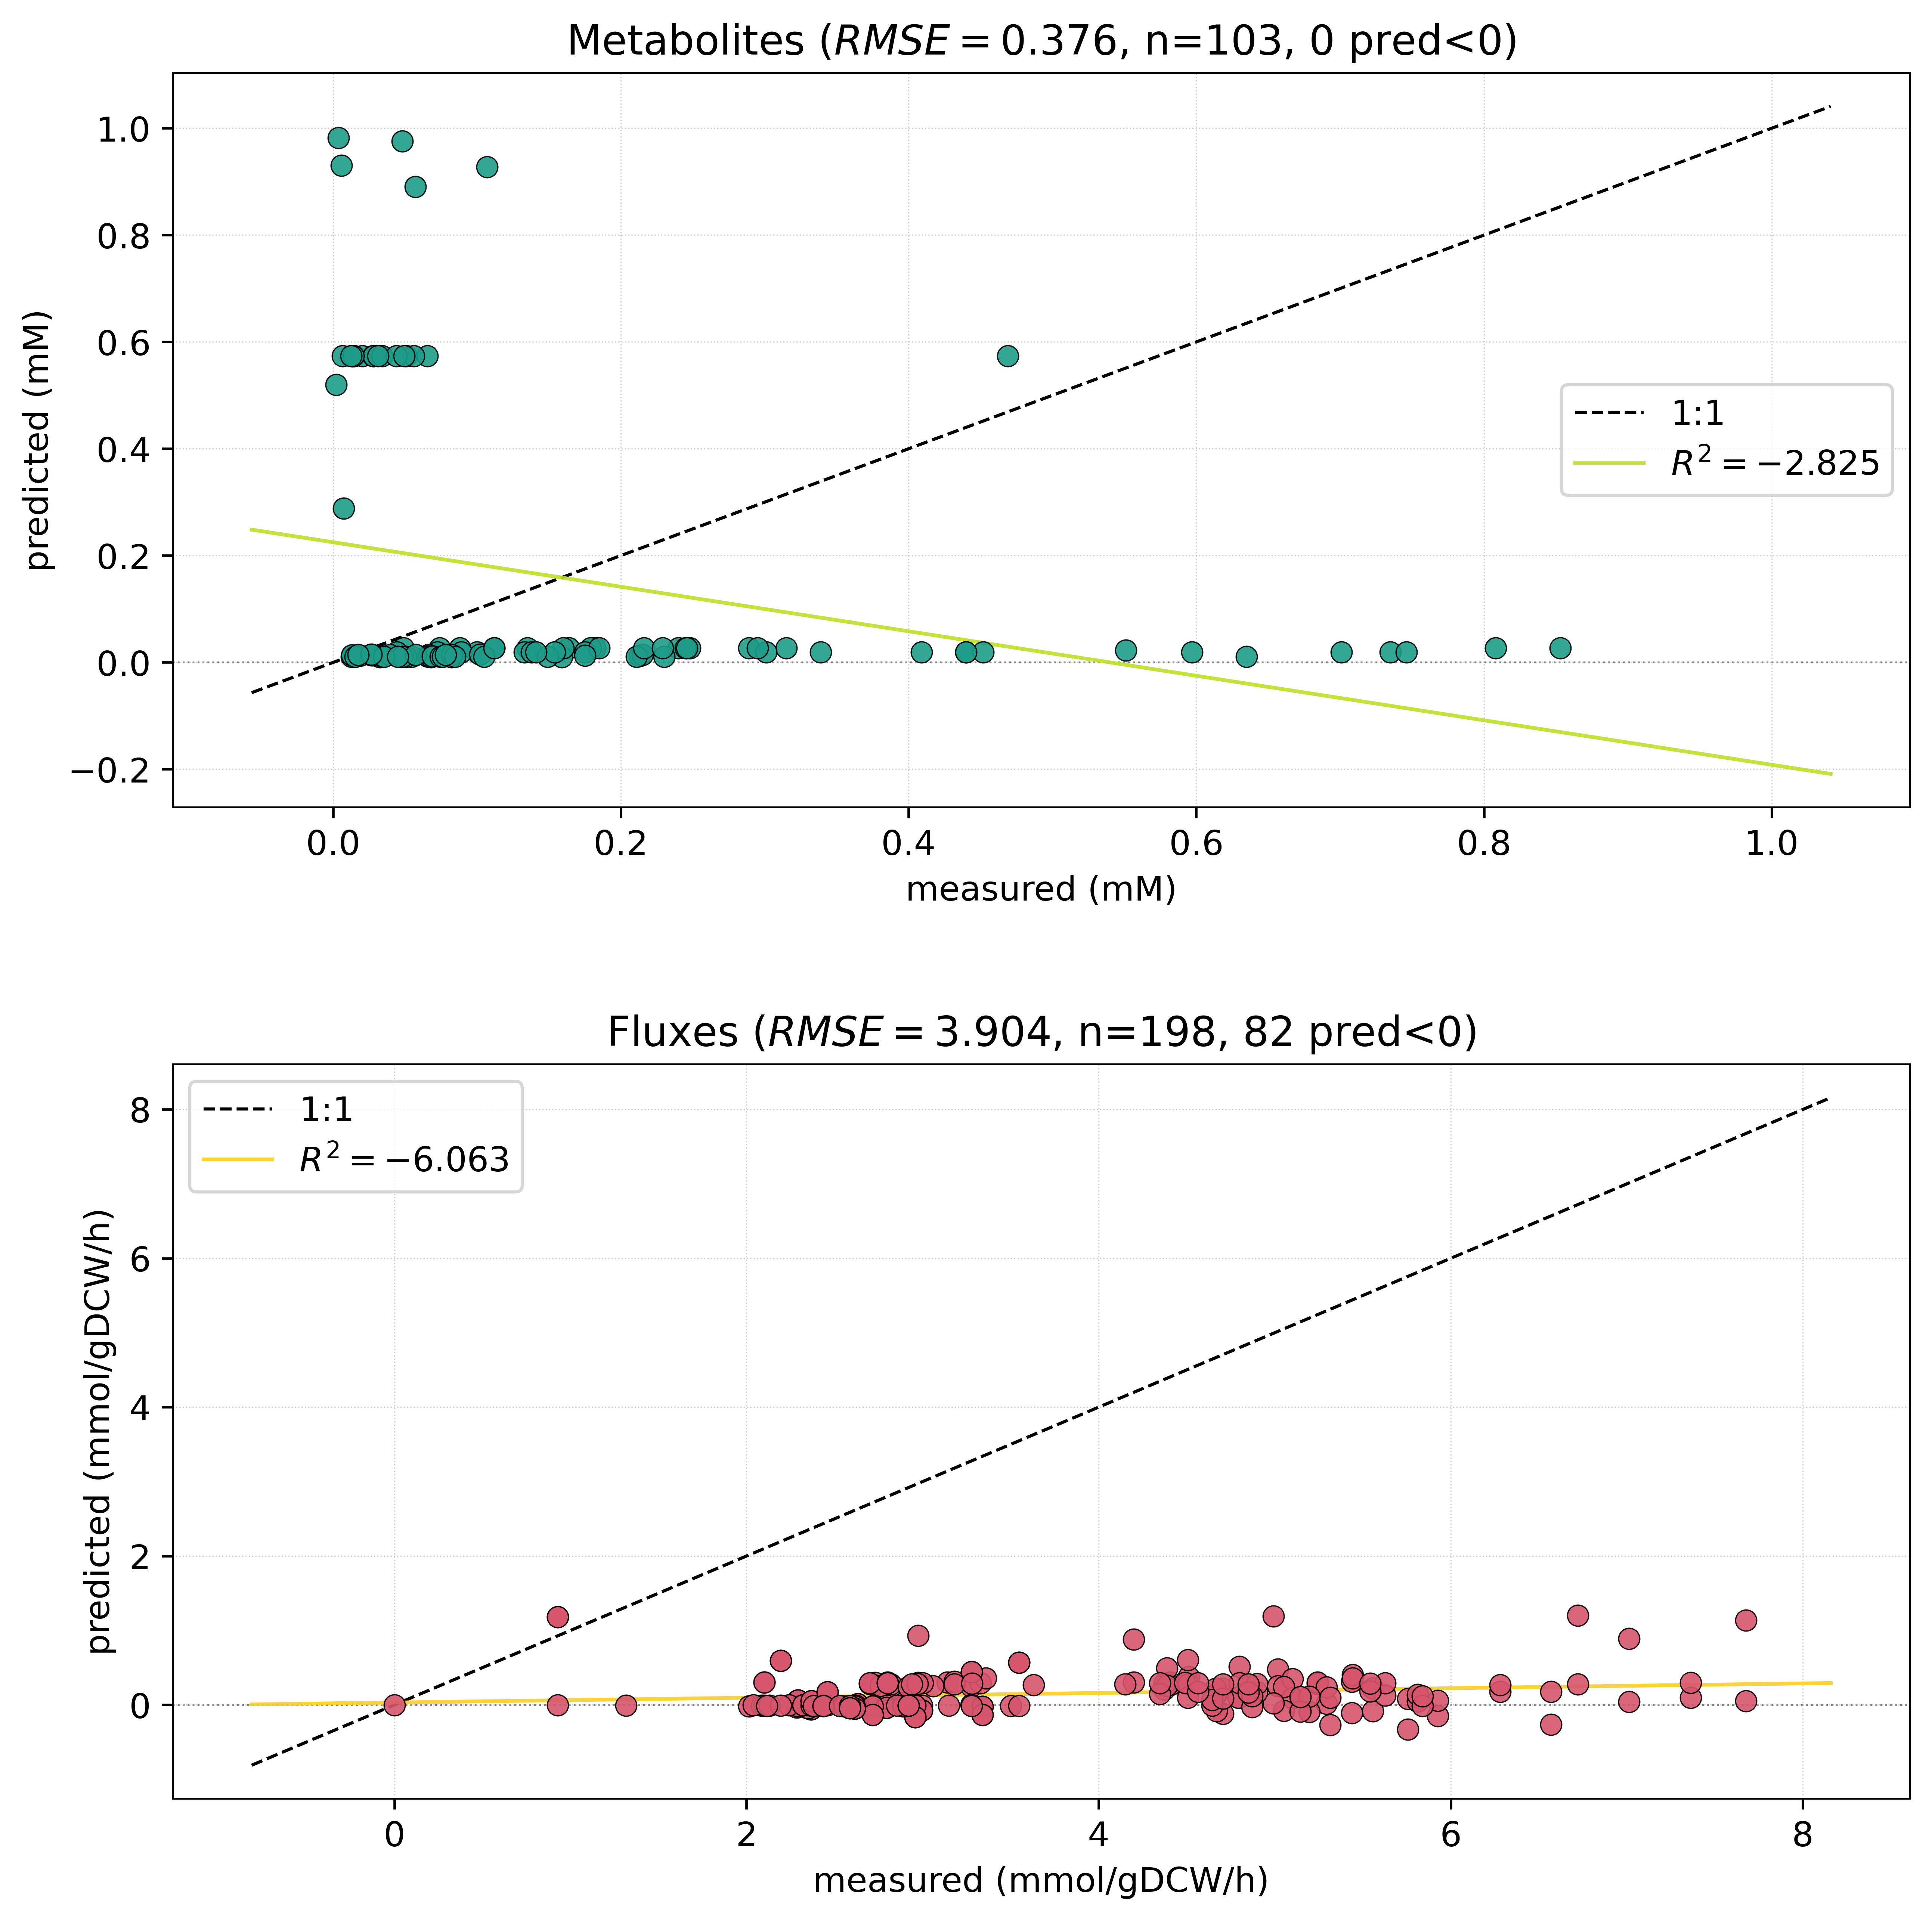

Saved: ['parity_fixed_metabolites.pdf', 'parity_fixed_fluxes.pdf']


In [8]:
# Model performance at LITERATURE/sampled theta: predicted vs measured.
# This is the a-priori (unfitted) model, so the fit is deliberately BAD -- this
# cell is written to SHOW EVERYTHING, no matter how bad: linear axes only (never
# log, which would silently drop negative fluxes), no value filtering, and every
# finite (measured, predicted) pair is plotted. Metabolites and fluxes are split
# into two panels because their scales differ. Reads only the saved CSVs.
from scipy.stats import linregress
from sklearn.metrics import r2_score, root_mean_squared_error

real_df = pd.read_csv(RESULTS_DIR / 'real.csv', index_col=0)
pred_df = pd.read_csv(RESULTS_DIR / 'predictions.csv', index_col=0)

# (col prefix, label, colormap, units, outfile)
GROUPS = [
    ('C_', 'Metabolites', 'viridis', '(mM)',          FIG_DIR / 'parity_fixed_metabolites.pdf'),
    ('v_', 'Fluxes',      'plasma',  '(mmol/gDCW/h)', FIG_DIR / 'parity_fixed_fluxes.pdf'),
]
MARKER_SIZE = 46

_rc_save = {k: mpl.rcParams[k] for k in (
    'font.family', 'font.size', 'axes.linewidth', 'mathtext.fontset')}
mpl.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':        11,
    'axes.linewidth':   0.6,
    'mathtext.fontset': 'dejavusans',
})

conds = [c for c in real_df.index if c in pred_df.index]
fig, ax = plt.subplots(2, 1, figsize=(10, 10), dpi=600,
                       gridspec_kw={'hspace': 0.35, 'height_ratios': [1, 1]})

for i, (prefix, label, cmap, units, outfile) in enumerate(GROUPS):
    group_cols = [c for c in real_df.columns if c.startswith(prefix)]
    xs, ys = [], []
    for cond in conds:
        for col in group_cols:
            rv = real_df.loc[cond, col]
            pv = pred_df.loc[cond, col]
            # ONLY skip cells with no measurement; never drop a bad/negative pred.
            if np.isfinite(rv) and np.isfinite(pv):
                xs.append(float(rv)); ys.append(float(pv))
    x, y = np.array(xs), np.array(ys)

    colors = plt.get_cmap(cmap)
    ax[i].scatter(x, y, color=colors(0.55), s=MARKER_SIZE, edgecolor='k',
                  linewidth=0.4, alpha=0.9, zorder=3)

    # Linear axes spanning ALL points (measured and predicted, incl. negatives).
    lo = min(x.min(), y.min()); hi = max(x.max(), y.max())
    pad = (hi - lo) * 0.06 or 0.1
    lo2, hi2 = lo - pad, hi + pad
    ax[i].plot([lo2, hi2], [lo2, hi2], 'k--', lw=1, zorder=2, label='1:1')
    ax[i].axhline(0, color='grey', lw=0.6, ls=':', zorder=1)  # mark unphysical y<0
    # ax[i].set_xlim(lo2, hi2); ax[i].set_ylim(lo2, hi2)

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2 = r2_score(x, y)
    ax[i].plot([lo2, hi2], [slope * lo2 + intercept, slope * hi2 + intercept],
               lw=1.2, zorder=2, label=r'$R^2=%.3f$' % r2, c=colors(0.9),
               alpha=0.9, linestyle='-')
    rmse = root_mean_squared_error(x, y)
    n_neg = int((y < 0).sum())
    ax[i].set_title(label + f' ($RMSE={rmse:.3f}$, n={len(x)}, {n_neg} pred<0)')
    ax[i].set_xlabel('measured ' + units); ax[i].set_ylabel('predicted ' + units)
    ax[i].grid(True, which='both', ls=':', lw=0.4, alpha=0.6)
    ax[i].legend(loc='best')
    print(f'{label}: plotted {len(x)} points  (predicted range {y.min():.3f}..{y.max():.3f}, '
          f'{n_neg} negative) -- all shown, none dropped')
    fig.savefig(outfile, dpi=300, bbox_inches='tight')

plt.show()
mpl.rcParams.update(_rc_save)
print('Saved:', [str(g[4].name) for g in GROUPS])
